In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
from google.colab import files
df = files.upload()


Saving Polynomial_data.csv to Polynomial_data (2).csv


In [18]:
#Read exel file
df = pd.read_csv('Polynomial_data.csv')
# Display first  rows
df.head()

,Temperature (C),Pressure (kPa),Unnamed: 2,Unnamed: 3,Extra Column
0,23.5,101.2,NaN,NaN,NaN
1,25.1,103.5,NaN,NaN,junk_data
2,NaN,105.8,NaN,NaN,NaN
3,27.3,NaN,NaN,NaN,NaN
4,28.9,110.2,NaN,NaN,NaN


In [19]:
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperature (C)  1059 non-null   object 
 1   Pressure (kPa)   1054 non-null   object 
 2   Unnamed: 2       0 non-null      float64
 3   Unnamed: 3       0 non-null      float64
 4   Extra Column     3 non-null      object 
dtypes: float64(2), object(3)
memory usage: 41.5+ KB
None

Summary Statistics:
       Unnamed: 2  Unnamed: 3
count         0.0         0.0
mean          NaN         NaN
std           NaN         NaN
min           NaN         NaN
25%           NaN         NaN
50%           NaN         NaN
75%           NaN         NaN
max           NaN         NaN


In [20]:
df.shape

(1060, 5)

In [21]:
df.isnull().any()

,0
Temperature (C),True
Pressure (kPa),True
Unnamed: 2,True
Unnamed: 3,True
Extra Column,True


In [22]:
df.isnull().sum()

,0
Temperature (C),1
Pressure (kPa),6
Unnamed: 2,1060
Unnamed: 3,1060
Extra Column,1057


In [11]:
df

,Temperature (C),Pressure (kPa),Unnamed: 2,Unnamed: 3,Extra Column
0,23.5,101.2,NaN,NaN,NaN
1,25.1,103.5,NaN,NaN,junk_data
2,NaN,105.8,NaN,NaN,NaN
3,27.3,NaN,NaN,NaN,NaN
4,28.9,110.2,NaN,NaN,NaN
...,...,...,...,...,...
1055,81.4,268.9,NaN,NaN,NaN
1056,82.4,273.6,NaN,NaN,NaN
1057,83.4,278.4,NaN,NaN,NaN
1058,84.4,283.2,NaN,NaN,NaN


In [23]:
null_percent = (df.isnull().sum() / len(df)) * 100
df

,Temperature (C),Pressure (kPa),Unnamed: 2,Unnamed: 3,Extra Column
0,23.5,101.2,NaN,NaN,NaN
1,25.1,103.5,NaN,NaN,junk_data
2,NaN,105.8,NaN,NaN,NaN
3,27.3,NaN,NaN,NaN,NaN
4,28.9,110.2,NaN,NaN,NaN
...,...,...,...,...,...
1055,81.4,268.9,NaN,NaN,NaN
1056,82.4,273.6,NaN,NaN,NaN
1057,83.4,278.4,NaN,NaN,NaN
1058,84.4,283.2,NaN,NaN,NaN


In [13]:
# Step 4: Drop completely empty / irrelevant columns
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Extra Column'], errors='ignore')

# View the cleaned dataframe
df

,Temperature (C),Pressure (kPa)
0,23.5,101.2
1,25.1,103.5
2,NaN,105.8
3,27.3,NaN
4,28.9,110.2
...,...,...
1055,81.4,268.9
1056,82.4,273.6
1057,83.4,278.4
1058,84.4,283.2


In [14]:
# Step 5: Rename columns for simplicity
df = df.rename(columns={'Temperature (C)': 'Temperature', 'Pressure (kPa)': 'Pressure'})

# Step 6: Convert object to numeric
# errors='coerce' converts non-numeric like "missing" or "N/A" to NaN
df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce')
df['Pressure'] = pd.to_numeric(df['Pressure'], errors='coerce')

In [15]:
# Step 7: Handle missing values by interpolation
df['Temperature'] = df['Temperature'].interpolate(method='linear')
df['Pressure'] = df['Pressure'].interpolate(method='linear')

# Step 8: Drop remaining missing rows (if any)
df = df.dropna(subset=['Temperature', 'Pressure'])



In [16]:
# Step 9: Reset index for clean structure
df = df.reset_index(drop=True)

# Step 10: Check cleaned dataset
print("\nCleaned Structured Dataset:\n", df.head(10))
print("\nDataset info after cleaning:")
print(df.info())


Cleaned Structured Dataset:
    Temperature  Pressure
0        23.50     101.2
1        25.10     103.5
2        26.20     105.8
3        27.30     108.0
4        28.90     110.2
5        30.20     112.5
6        31.80     114.8
7        33.40     117.1
8        34.75     119.3
9        36.10     121.8

Dataset info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  1060 non-null   float64
 1   Pressure     1060 non-null   float64
dtypes: float64(2)
memory usage: 16.7 KB
None


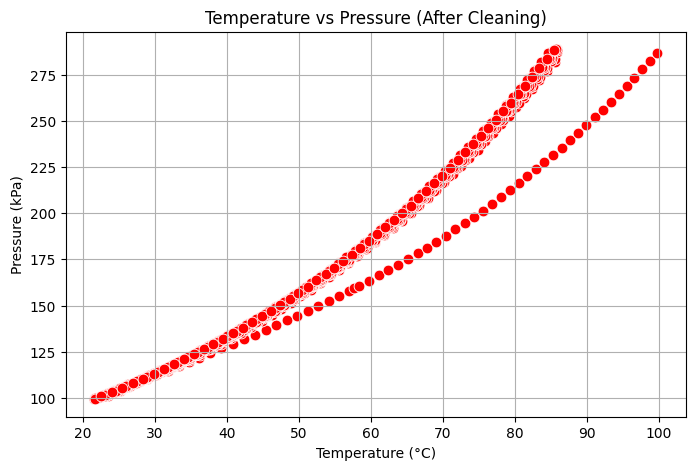

In [17]:
# Visualization to verify
plt.figure(figsize=(8,5))
sns.scatterplot(x='Temperature', y='Pressure', data=df, color='red', s=60)
plt.title("Temperature vs Pressure (After Cleaning)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Pressure (kPa)")
plt.grid(True)
plt.show()

In [18]:
# To develop a Polynomial Regression model that predicts the pressure (kPa) of a gas from its temperature (°C)

# Independent and dependent variables
X = df[['Temperature']].values
y = df['Pressure'].values



In [19]:
# Step 3: Linear Regression (Baseline)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
r2_linear = r2_score(y, y_pred_linear)

# Step 4: Polynomial Regression (Degree 2 and 3)

# Degree 2 (Quadratic)
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)

poly_reg2 = LinearRegression()
poly_reg2.fit(X_poly2, y)
y_pred_poly2 = poly_reg2.predict(X_poly2)
r2_poly2 = r2_score(y, y_pred_poly2)

In [20]:
# Degree 3 (Cubic) - optional comparison
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X)

poly_reg3 = LinearRegression()
poly_reg3.fit(X_poly3, y)
y_pred_poly3 = poly_reg3.predict(X_poly3)
r2_poly3 = r2_score(y, y_pred_poly3)

In [21]:
# Step 5: Evaluate Models
print("\nModel Performance Comparison:")
print(f"Linear Regression R² Score: {r2_linear:.4f}")
print(f"Polynomial (Degree 2) R² Score: {r2_poly2:.4f}")
print(f"Polynomial (Degree 3) R² Score: {r2_poly3:.4f}")


Model Performance Comparison:
Linear Regression R² Score: 0.9640
Polynomial (Degree 2) R² Score: 0.9772
Polynomial (Degree 3) R² Score: 0.9799


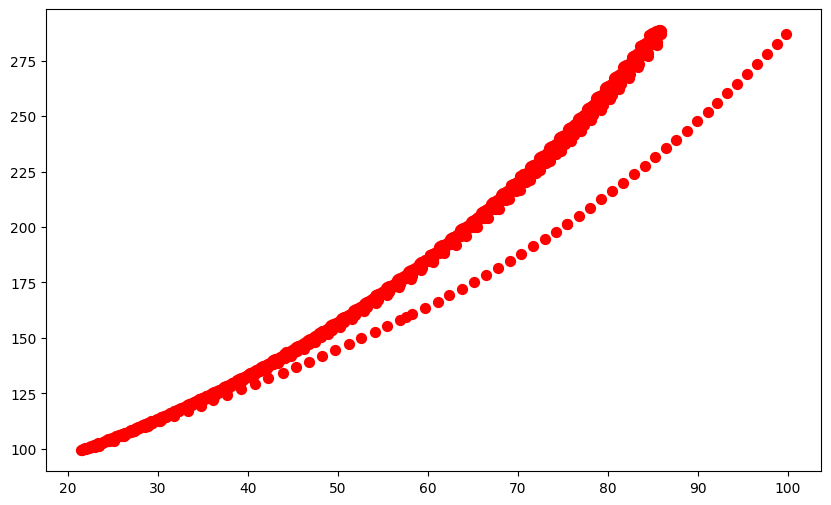

In [22]:
plt.figure(figsize=(10,6))

# Scatter plot of original data
plt.scatter(X, y, color='red', s=50, label='Actual Data')


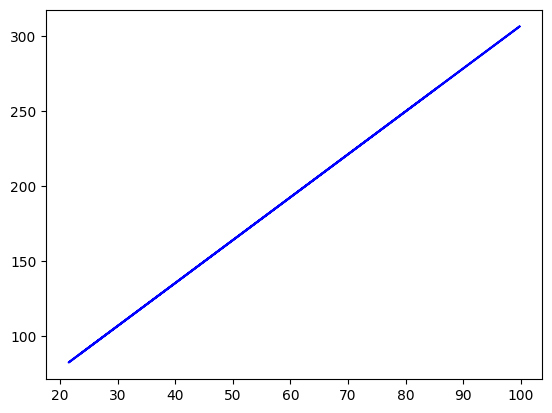

In [23]:
# Linear Regression line
plt.plot(X, y_pred_linear, color='blue', label=f'Linear Fit (R²={r2_linear:.3f})')

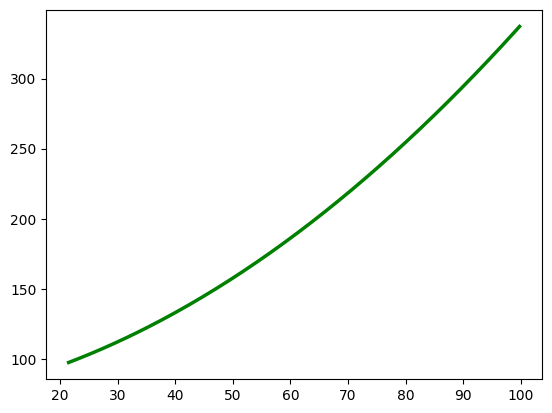

In [25]:
# Polynomial (Degree 2) curve
X_grid = np.linspace(min(X), max(X), 200).reshape(-1,1)
plt.plot(X_grid, poly_reg2.predict(poly2.transform(X_grid)), color='green', linewidth=2.5,
         label=f'Polynomial (Degree 2) Fit (R²={r2_poly2:.3f})')

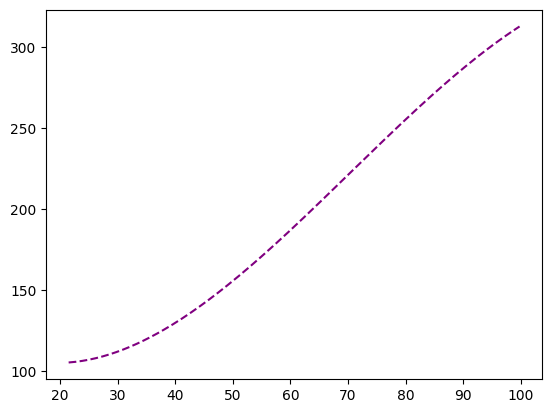

In [26]:
# Polynomial (Degree 3) curve
plt.plot(X_grid, poly_reg3.predict(poly3.transform(X_grid)), color='purple', linestyle='--',
         label=f'Polynomial (Degree 3) Fit (R²={r2_poly3:.3f})')

In [27]:
# Step 7: Model Evaluation Metrics
from sklearn.metrics import mean_squared_error

mse_poly2 = mean_squared_error(y, y_pred_poly2)
mse_poly3 = mean_squared_error(y, y_pred_poly3)

print("\nPolynomial Regression Model Details:")
print(f"Degree 2 Coefficients: {poly_reg2.coef_}")
print(f"Degree 2 Intercept: {poly_reg2.intercept_}")
print(f"Degree 2 MSE: {mse_poly2:.4f}")

print(f"\nDegree 3 Coefficients: {poly_reg3.coef_}")
print(f"Degree 3 Intercept: {poly_reg3.intercept_}")
print(f"Degree 3 MSE: {mse_poly3:.4f}")


Polynomial Regression Model Details:
Degree 2 Coefficients: [0.         0.74868911 0.01906771]
Degree 2 Intercept: 72.52517116001124
Degree 2 MSE: 68.7275

Degree 3 Coefficients: [ 0.00000000e+00 -3.16697391e+00  9.41554403e-02 -4.46191326e-04]
Degree 3 Intercept: 134.39239366293862
Degree 3 MSE: 60.6504
